
STEP 1: Loading Netflix Dataset...
Dataset loaded successfully!

Displaying First 5 Rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 mi

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN



STEP 3: Checking Missing Values


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


STEP 4: Removing Duplicate Records
Number of duplicate rows found: 0
Duplicate records removed successfully!

STEP 5: Checking Data Types


show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


STEP 6: Converting 'date_added' to Datetime Format
Date conversion completed!

VISUALIZATION 1: Movies vs TV Shows


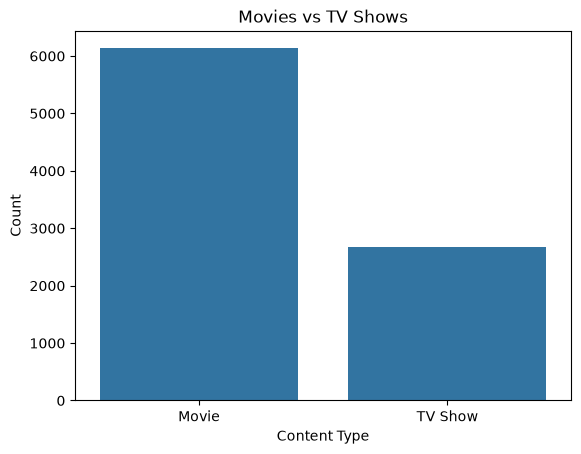


VISUALIZATION 2: Content Added by Year


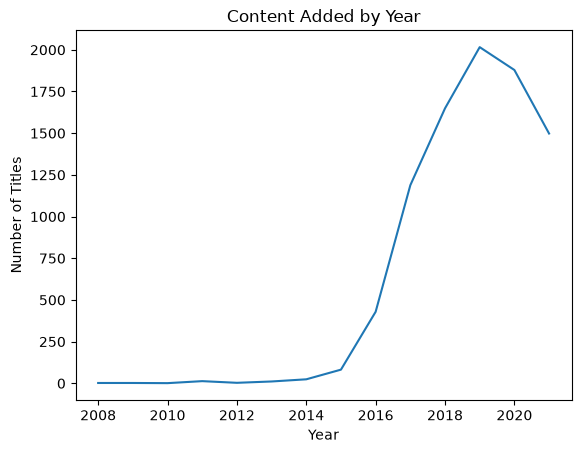


VISUALIZATION 3: Top 10 Content Producing Countries


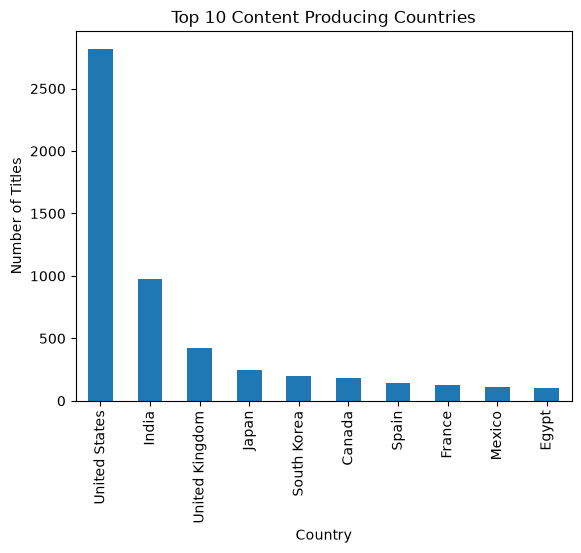


VISUALIZATION 4: Content Rating Distribution


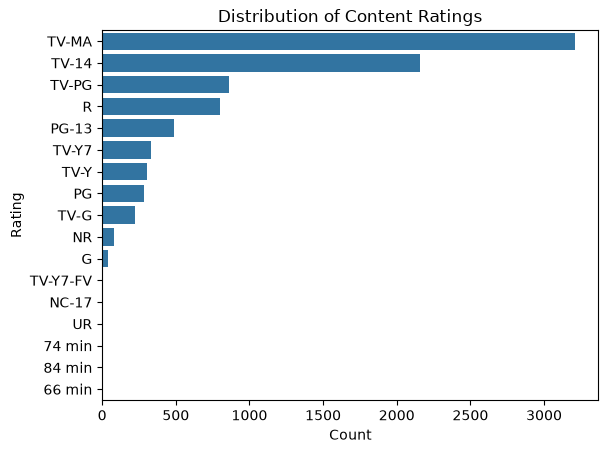


VISUALIZATION 5: Top 10 Genres on Netflix


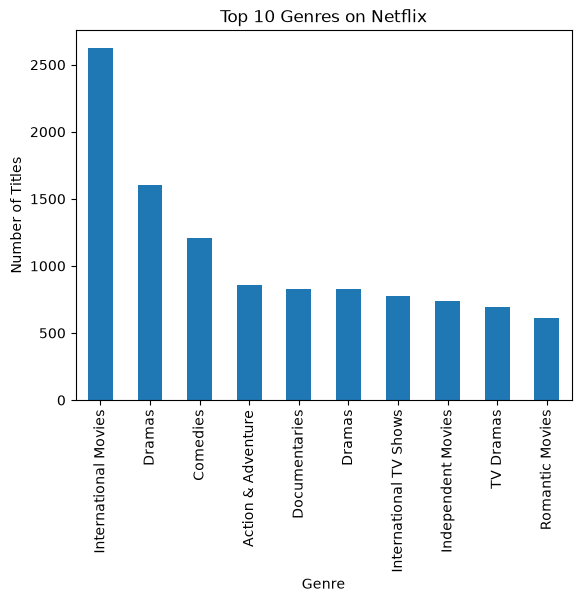


________________
PROJECT SUMMARY
__________________
1. Loaded Netflix dataset successfully.
2. Examined dataset structure and statistics.
3. Identified missing values.
4. Removed duplicate records.
5. Converted date_added column into datetime format.
6. Created visualizations for content type, yearly additions, countries, ratings, and genres.

KEY INSIGHTS:
- Netflix contains more Movies than TV Shows.
- Content additions increased significantly over the years.
- The United States contributes the highest amount of content.
- TV-MA and TV-14 are among the most common ratings.
- Drama and International Movies are highly popular genres.

Project completed successfully!


In [13]:
# _______________________________________________
# Netflix Data Cleaning & Visualization Project
# _______________________________________________

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load Dataset

print("\nSTEP 1: Loading Netflix Dataset...")

df = pd.read_csv(
    r"C:\Users\supra\Documents\Netflix-Data-Cleaning-Visualization\data\netflix_titles.csv"
)

print("Dataset loaded successfully!")

# Display first 5 rows
print("\nDisplaying First 5 Rows:")
print(df.head())

# Step 2: Understand Dataset

print("\nSTEP 2: Understanding Dataset Structure")

print("\nDataset Shape (Rows, Columns):")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns)

print("\nDescriptive Statistics:")
display(df.describe(include='all'))

# Step 3: Check Missing Values

print("\nSTEP 3: Checking Missing Values")

missing_values = df.isnull().sum()
display(missing_values)


# Step 4: Remove Duplicates

print("\nSTEP 4: Removing Duplicate Records")

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

df.drop_duplicates(inplace=True)

print("Duplicate records removed successfully!")


# Step 5: Check Data Types

print("\nSTEP 5: Checking Data Types")

display(df.dtypes)

# Step 6: Convert Date Column

print("\nSTEP 6: Converting 'date_added' to Datetime Format")

df['date_added'] = pd.to_datetime(
    df['date_added'].str.strip(),
    format='%B %d, %Y',
    errors='coerce'
)

print("Date conversion completed!")

# Create year column for analysis
df['year_added'] = df['date_added'].dt.year


# Visualization 1

print("\nVISUALIZATION 1: Movies vs TV Shows")

sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

# Visualization 2

print("\nVISUALIZATION 2: Content Added by Year")

df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()


# Visualization 3

print("\nVISUALIZATION 3: Top 10 Content Producing Countries")

df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

# Visualization 4

print("\nVISUALIZATION 4: Content Rating Distribution")

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Distribution of Content Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()


# Visualization 5
print("\nVISUALIZATION 5: Top 10 Genres on Netflix")

df['listed_in'].str.split(',').explode().value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.show()


# Project Summary

print("\n________________")
print("PROJECT SUMMARY")
print("__________________")



print("1. Loaded Netflix dataset successfully.")
print("2. Examined dataset structure and statistics.")
print("3. Identified missing values.")
print("4. Removed duplicate records.")
print("5. Converted date_added column into datetime format.")
print("6. Created visualizations for content type, yearly additions, countries, ratings, and genres.")

print("\nKEY INSIGHTS:")
print("- Netflix contains more Movies than TV Shows.")
print("- Content additions increased significantly over the years.")
print("- The United States contributes the highest amount of content.")
print("- TV-MA and TV-14 are among the most common ratings.")
print("- Drama and International Movies are highly popular genres.")

print("\nProject completed successfully!")